## 11.

(d) An image is corrupted by high-frequency noise. Justify which of the above filters is
most suitable for noise reduction, using both spatial and frequency domain arguments.


Create an image corrupted with salt and pepper noise.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

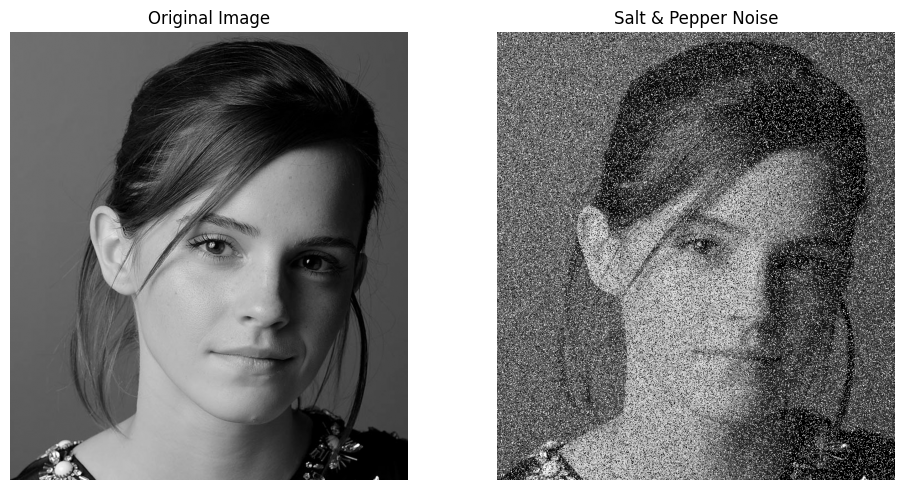

In [3]:
s = f.copy()
prob = 0.3 


salt = np.random.rand(*f.shape) < prob / 2
s[salt] = 255


pepper = np.random.rand(*f.shape) < prob / 2
s[pepper] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Salt & Pepper Noise')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Box filter

In [4]:
box = cv.blur(s, (5, 5))

### Gaussian filter (manual kernel)

In [5]:
sigma = 2
h_size = 3 * sigma
x = np.arange(-h_size, h_size + 1, 1)
y = np.arange(-h_size, h_size + 1, 1)
Y, X = np.meshgrid(x, y)
g = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
g = g / np.sum(g)
gaussian = cv.filter2D(s, -1, g)

### Laplacian

In [7]:
laplacian = cv.Laplacian(s, cv.CV_8U)

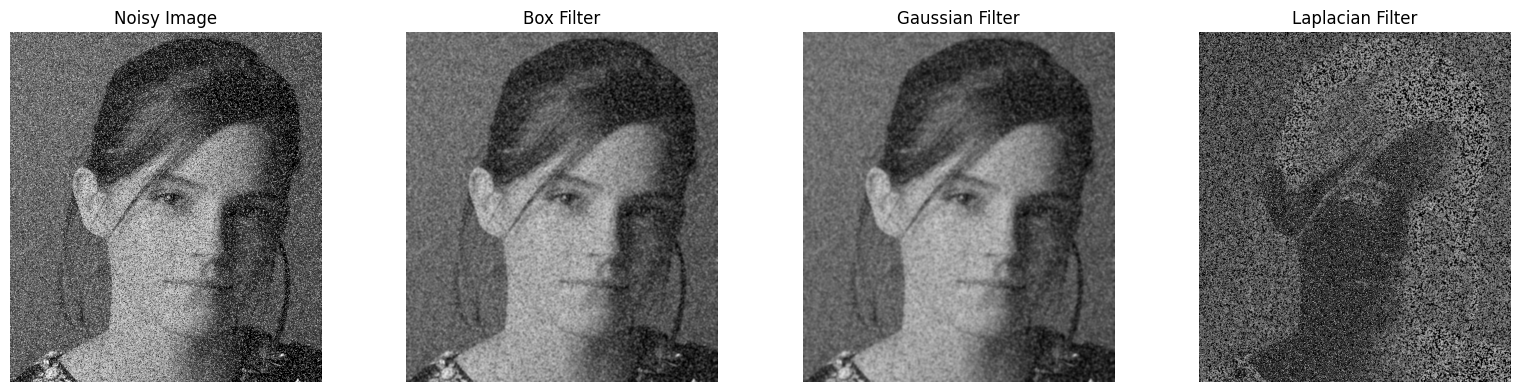

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(s, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Noisy Image')
ax[0].axis('off')

ax[1].imshow(box, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Box Filter')
ax[1].axis('off')

ax[2].imshow(gaussian, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Gaussian Filter')
ax[2].axis('off')

ax[3].imshow(laplacian, cmap='gray', vmin=0, vmax=255)
ax[3].set_title('Laplacian Filter')
ax[3].axis('off')

plt.tight_layout()
plt.show()